# Exploratory Data Analysis

## 1. Spatial Analysis

This code block creates a heatmap of Singapore's districts, visualizing the average property price per square foot (SGD/sqft) by merging geographic planning area data from a GeoJSON file with district-price mappings, then plotting the results with custom colors and labels.


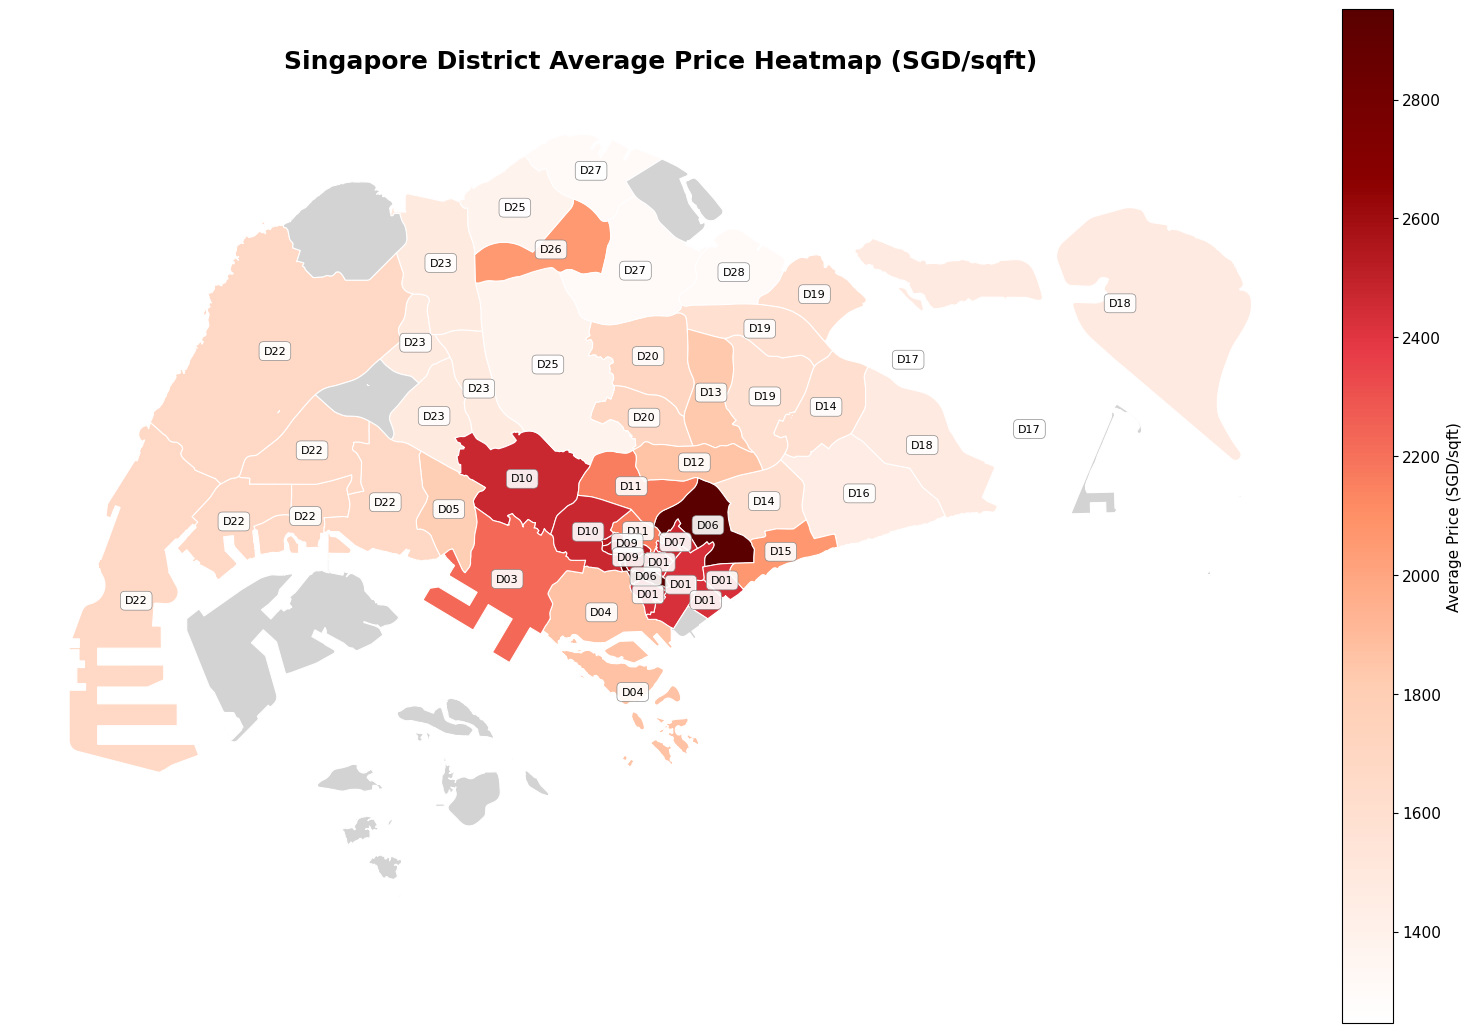

In [10]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

district_mapping = {
    1: ['Downtown Core', 'Marina East', 'Marina South', 'Museum', 'Outram'],
    2: ['Tanjong Pagar', 'Downtown Core'],
    3: ['Queenstown', 'Tiong Bahru'],
    4: ['Bukit Merah', 'Southern Islands'],
    5: ['Clementi'],
    6: ['Kallang', 'Singapore River'],
    7: ['Rochor', 'Singapore River'],
    8: ['Rochor'],
    9: ['Orchard', 'River Valley'],
    10: ['Bukit Timah', 'Tanglin'],
    11: ['Novena', 'Newton'],
    12: ['Toa Payoh', 'Novena'],
    13: ['Toa Payoh', 'Serangoon'],
    14: ['Geylang', 'Paya Lebar'],
    15: ['Marine Parade'],
    16: ['Bedok'],
    17: ['Changi', 'Pasir Ris'],
    18: ['Tampines', 'Pasir Ris', 'North-Eastern Islands'],
    19: ['Serangoon', 'Hougang', 'Punggol', 'Sengkang', 'North-Eastern Islands'],
    20: ['Bishan', 'Ang Mo Kio'],
    21: ['Bukit Timah'],
    22: ['Jurong East', 'Jurong West', 'Boon Lay', 'Pioneer', 'Tuas', 'Western Water Catchment'],
    23: ['Bukit Panjang', 'Choa Chu Kang', 'Bukit Batok', 'Sungei Kadut', 'Western Water Catchment'],
    24: ['Lim Chu Kang', 'Tengah', 'Western Water Catchment'],
    25: ['Woodlands', 'Central Water Catchment', 'Sungei Kadut'],
    26: ['Bishan', 'Mandai'],
    27: ['Yishun', 'Sembawang'],
    28: ['Seletar']
}

planning_to_district = []
for district, planning_areas in district_mapping.items():
    for area in planning_areas:
        planning_to_district.append({'Planning Area': area, 'District': district})
planning_to_district = pd.DataFrame(planning_to_district)
planning_to_district = planning_to_district.drop_duplicates(subset=['Planning Area'], keep='first')

price_data = pd.DataFrame({
    'District': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28],
    'Avg_Price': [2430.83, 2233.32, 2231.35, 1867.21, 1796.14, 2951.61, 2467.07, 1756.75, 2534.54, 2465.35, 
                  2159.48, 1859.85, 1835.87, 1598.27, 2061.58, 1441.01, 1246.32, 1477.88, 1592.33, 1706.99, 
                  1951.02, 1669.26, 1481.49, 1373.12, 2058.44, 1304.41, 1311.05]
})

gdf_subzones = gpd.read_file('../datasets/supplementary_datasets/master_planning_area.geojson')
gdf = gdf_subzones.dissolve(by='PLN_AREA_N', as_index=False)

gdf['PLN_AREA_N'] = gdf['PLN_AREA_N'].str.title()
planning_to_district['Planning Area'] = planning_to_district['Planning Area'].str.title()

gdf = gdf.merge(planning_to_district, left_on='PLN_AREA_N', right_on='Planning Area', how='left')
gdf = gdf.merge(price_data[['District', 'Avg_Price']], on='District', how='left')

fig, ax = plt.subplots(figsize=(16, 13))
colors = ['#FFFFFF', '#FFE5D9', '#FFCDB2', '#FF9066', '#E63946', '#8B0000', '#5A0000']
cmap = LinearSegmentedColormap.from_list('price_premium', colors, N=256)

# Plot using actual prices
gdf.plot(column='Avg_Price', 
         cmap=cmap,
         linewidth=0.8,
         edgecolor='white',
         legend=True,
         ax=ax,
         missing_kwds={'color': 'lightgrey'},
         legend_kwds={'label': 'Average Price (SGD/sqft)',
                      'orientation': 'vertical',
                      'shrink': 0.8,
                      'pad': 0.02})

for idx, row in gdf.iterrows():
    if pd.notna(row['District']) and pd.notna(row['Avg_Price']):
        centroid = row['geometry'].centroid
        ax.text(centroid.x, centroid.y, f"D{int(row['District']):02d}", 
                fontsize=8, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                         edgecolor='gray', linewidth=0.5, alpha=0.9))

ax.set_title('Singapore District Average Price Heatmap (SGD/sqft)', 
             fontsize=18, weight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=13)
ax.set_ylabel('Latitude', fontsize=13)
ax.axis('off')

plt.tight_layout()
plt.show()

unmapped = gdf[gdf['District'].isna()]['PLN_AREA_N'].unique()

## 2. Temporal Analysis

This code block attempts to load multiple CSV files containing residential property transaction data, concatenates them into a single DataFrame, and cleans numeric columns by removing commas and converting them to numeric types.

In [5]:
import pandas as pd

file_paths = [
    '../datasets/supplementary_datasets/URA_Private_Property_Transaction_Data/ResidentialTransaction20250928153646.csv',
    '../datasets/supplementary_datasets/URA_Private_Property_Transaction_Data/ResidentialTransaction20250928153756.csv',
    '../datasets/supplementary_datasets/URA_Private_Property_Transaction_Data/ResidentialTransaction20250928153904.csv',
    '../datasets/supplementary_datasets/URA_Private_Property_Transaction_Data/ResidentialTransaction20250928154043.csv',
    '../datasets/supplementary_datasets/URA_Private_Property_Transaction_Data/ResidentialTransaction20250928154154.csv',
    '../datasets/supplementary_datasets/URA_Private_Property_Transaction_Data/ResidentialTransaction20250928154242.csv'
]

try:
    df_list = [pd.read_csv(file_path, encoding='latin-1') for file_path in file_paths]
    combined_df = pd.concat(df_list, ignore_index=True)
    columns_to_clean = ['Unit Price ($ PSF)', 'Transacted Price ($)', 'Area (SQFT)']
    
    for col in columns_to_clean:
        if col in combined_df.columns:
            combined_df[col] = combined_df[col].astype(str).str.replace(',', '', regex=False)
            combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')
        else:
            print(f"Warning: Column '{col}' not found in the combined data. Skipping cleaning.")



except Exception as e:
    print(f"\nERROR: Failed during CSV processing or concatenation.")
    print(f"Reason: {e}")
    combined_df = pd.DataFrame()

Starting CSV combination...


This code analyzes property transaction data by filtering for years 2023-2025, identifying the top 5 districts with the highest transaction volume, and visualizing the average monthly price per square foot (PSF) for these districts using a line chart with distinct colors for each district.

/var/folders/lt/sfjl1trs6n7996zzzjjjcyrw0000gn/T/ipykernel_35076/2671656766.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_districts_df['YearMonth'] = top_districts_df['YearMonth'].astype(str)


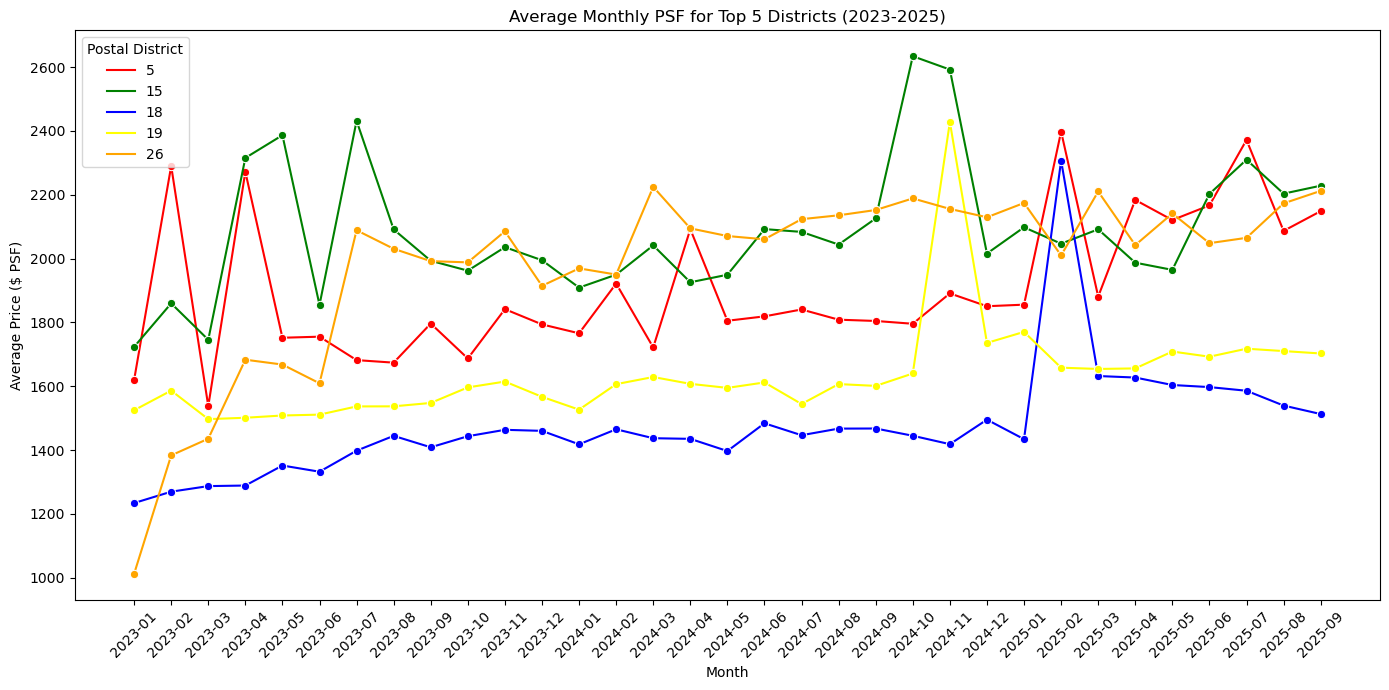

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

combined_df['Sale Date'] = pd.to_datetime(combined_df['Sale Date'], format='%b-%y')

filtered_df = combined_df[(combined_df['Sale Date'].dt.year >= 2023) & (combined_df['Sale Date'].dt.year <= 2025)]

filtered_df['YearMonth'] = filtered_df['Sale Date'].dt.to_period('M')

district_volume = filtered_df.groupby(['YearMonth', 'Postal District']).size().reset_index(name='Transaction Volume')

top_districts = (
    district_volume.groupby('Postal District')['Transaction Volume']
    .sum()
    .nlargest(5)
    .index
)

top_districts_df = district_volume[district_volume['Postal District'].isin(top_districts)]

top_districts_df['YearMonth'] = top_districts_df['YearMonth'].astype(str)

avg_psf_monthly = filtered_df[filtered_df['Postal District'].isin(top_districts)].groupby(
    ['YearMonth', 'Postal District']
)['Unit Price ($ PSF)'].mean().reset_index()

avg_psf_monthly['YearMonth'] = avg_psf_monthly['YearMonth'].astype(str)

custom_palette = ['red', 'green', 'blue', 'yellow', 'orange']

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=avg_psf_monthly,
    x='YearMonth',
    y='Unit Price ($ PSF)',
    hue='Postal District',
    palette=custom_palette,
    marker='o'
)
plt.title('Average Monthly PSF for Top 5 Districts (2023-2025)')
plt.xlabel('Month')
plt.ylabel('Average Price ($ PSF)')
plt.xticks(rotation=45)
plt.legend(title='Postal District', loc='upper left')
plt.tight_layout()
plt.show()

## Market Activity

This code creates a dual-axis bar and line chart to visualize the relationship between the average price per square foot (PSF) and the transaction count for the top 20 most active districts, ranked by transaction count.


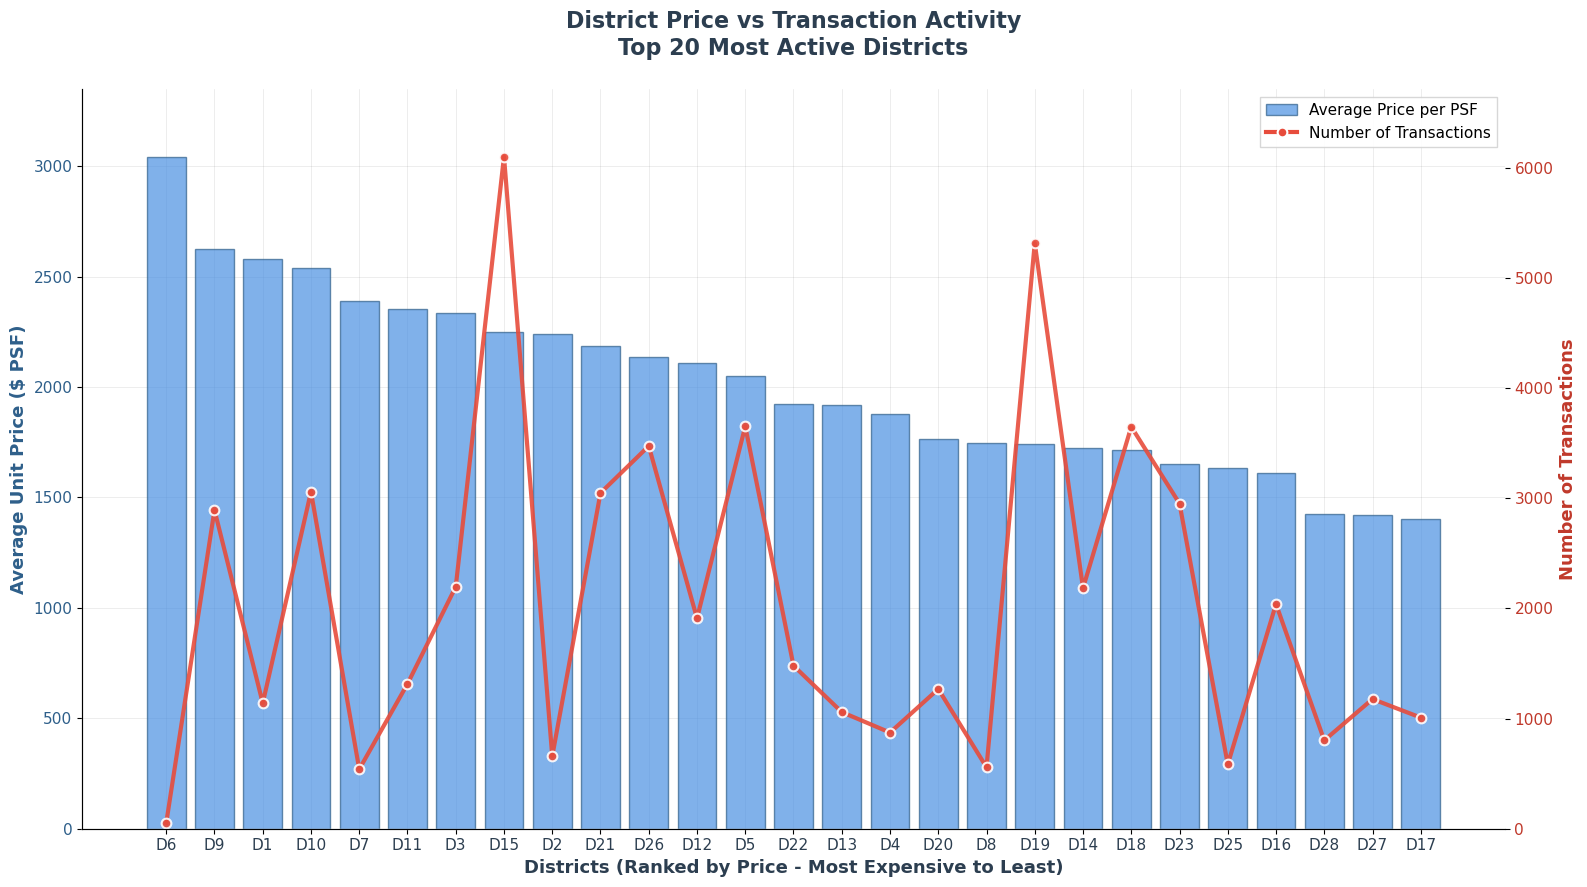

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

plt.style.use('default')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

district_analysis = combined_df.groupby('Postal District').agg({
    'Unit Price ($ PSF)': 'mean',
    'Transacted Price ($)': 'count',
    'Area (SQFT)': 'mean'
}).round(0)

district_analysis.columns = ['Avg_PSF', 'Transaction_Count', 'Avg_Size']
district_analysis = district_analysis.reset_index()

top_active = district_analysis.nlargest(28, 'Transaction_Count')
top_20_districts = top_active.sort_values('Avg_PSF', ascending=False)

fig, ax1 = plt.subplots(figsize=(16, 9))

x_pos = np.arange(len(top_20_districts))
district_labels = [f'D{d}' for d in top_20_districts['Postal District']]

bars = ax1.bar(x_pos, top_20_districts['Avg_PSF'], 
               color='#4A90E2', alpha=0.7, edgecolor='#2E5F8A', linewidth=1,
               width=0.8)

ax1.set_ylabel('Average Unit Price ($ PSF)', fontsize=13, fontweight='600', color='#2E5F8A')
ax1.tick_params(axis='y', labelcolor='#2E5F8A', labelsize=11)

ax2 = ax1.twinx()
line = ax2.plot(x_pos, top_20_districts['Transaction_Count'], 
                color='#E74C3C', marker='o', linewidth=3, markersize=7, 
                markerfacecolor='#E74C3C', markeredgecolor='white', markeredgewidth=1.5,
                alpha=0.9)

ax2.set_ylabel('Number of Transactions', fontsize=13, fontweight='600', color='#C0392B')
ax2.tick_params(axis='y', labelcolor='#C0392B', labelsize=11)

ax1.set_xlabel('Districts (Ranked by Price - Most Expensive to Least)', 
               fontsize=13, fontweight='600', color='#2C3E50')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(district_labels, fontsize=11, color='#2C3E50')

ax1.set_title('District Price vs Transaction Activity\nTop 20 Most Active Districts', 
              fontsize=16, fontweight='700', color='#2C3E50', pad=25)

ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, color='gray')
ax1.set_axisbelow(True)

from matplotlib.lines import Line2D
legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor='#4A90E2', alpha=0.7, edgecolor='#2E5F8A', 
                  label='Average Price per PSF'),
    Line2D([0], [0], color='#E74C3C', linewidth=3, marker='o', markersize=7,
           markerfacecolor='#E74C3C', markeredgecolor='white', markeredgewidth=1.5,
           label='Number of Transactions')
]

ax1.legend(handles=legend_elements, loc='upper right', fontsize=11, 
          frameon=True, fancybox=False, shadow=False, 
          framealpha=0.9, edgecolor='lightgray')

fig.patch.set_facecolor('white')
ax1.set_facecolor('white')

ax1.set_ylim(0, max(top_20_districts['Avg_PSF']) * 1.1)
ax2.set_ylim(0, max(top_20_districts['Transaction_Count']) * 1.1)

plt.tight_layout()

for spine in ax1.spines.values():
    spine.set_color('#CCCCCC')
    spine.set_linewidth(1)

plt.show()

## Demographic Analysis

This code processes a Singapore demographics CSV file by cleaning and restructuring the data to include planning areas, subzones, and age groups as columns, while converting numeric fields to integers and handling missing or invalid values, resulting in a cleaned and organized DataFrame for further analysis.

In [ ]:
import pandas as pd
import re

def clean_singapore_demographics_csv(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        lines = file.readlines()
    
    data_lines = []
    current_planning_area = None
    
    for line in lines:
        parts = [part.strip() for part in line.split(';')]
        
        if len(parts) < 20:
            continue
        
        if (parts[1] in ['GENERAL HOUSEHOLD SURVEY 2015', 'Table 7', 'Planning Area', '', 'Note:'] or
            'continued' in parts[1] or 'Number' in parts[1] or parts[1] == 'Total'):
            continue
        
        if parts[1] and parts[1] != '' and not parts[1].startswith(' '):
            current_planning_area = parts[1]
            
            if parts[2] and parts[2] != '':
                clean_row = [current_planning_area, 'Total'] + parts[3:]
                data_lines.append(clean_row)
        
        elif not parts[1] and parts[2] and current_planning_area:
            clean_row = [current_planning_area, parts[2]] + parts[3:]
            data_lines.append(clean_row)
    
    columns = ['Planning_Area', 'Subzone', 'Total', 'Age_0_4', 'Age_5_9', 'Age_10_14', 
               'Age_15_19', 'Age_20_24', 'Age_25_29', 'Age_30_34', 'Age_35_39', 
               'Age_40_44', 'Age_45_49', 'Age_50_54', 'Age_55_59', 'Age_60_64', 
               'Age_65_69', 'Age_70_74', 'Age_75_79', 'Age_80_84', 'Age_85_Over']
    
    df = pd.DataFrame(data_lines, columns=columns)
    
    for col in columns[2:]:  
        df[col] = df[col].apply(clean_numeric)
    
    numeric_cols = columns[2:]
    df = df[df[numeric_cols].sum(axis=1) > 0]
    
    df = df.reset_index(drop=True)
    
    return df

def clean_numeric(value):
    """Clean numeric values - remove dots used as thousands separators, handle dashes"""
    if pd.isna(value) or value == '' or value == '-':
        return 0
    
    if isinstance(value, str):
        value = re.sub(r'(\d)\.(\d{3})', r'\1\2', value)
        value = re.sub(r'(\d)\.(\d{3})', r'\1\2', value)  
        
        try:
            return int(value)
        except:
            return 0
    
    return value


cleaned_df = clean_singapore_demographics_csv('../datasets//supplementary_datasets/SingaporeStatistic_Residential_AgeGroup/SingStat_ResidentPopulationBy_AgeGroup.csv')

pd.set_option('display.max_columns', None)  
pd.set_option('display.max_rows', 50)     
pd.set_option('display.width', None)       
pd.set_option('display.max_colwidth', 20)  

This code creates new columns in the cleaned_df DataFrame to group age ranges into three demographic categories: Young Adults (20-35), Families (36-59), and Retirees (60+), then filters the data to only include totals for each planning area and selects relevant columns for demographic analysis, resulting in a summarized DataFrame (district_demographics).


In [ ]:
# Create age groups
cleaned_df['Young_Adults_20_35'] = (cleaned_df['Age_20_24'] + cleaned_df['Age_25_29'] + 
                                   cleaned_df['Age_30_34'] + cleaned_df['Age_35_39'])

cleaned_df['Families_36_59'] = (cleaned_df['Age_35_39'] + cleaned_df['Age_40_44'] + 
                               cleaned_df['Age_45_49'] + cleaned_df['Age_50_54'] + 
                               cleaned_df['Age_55_59'])

cleaned_df['Retirees_60_Plus'] = (cleaned_df['Age_60_64'] + cleaned_df['Age_65_69'] + 
                                 cleaned_df['Age_70_74'] + cleaned_df['Age_75_79'] + 
                                 cleaned_df['Age_80_84'] + cleaned_df['Age_85_Over'])

# Filter to only planning area totals and select relevant columns
district_demographics = cleaned_df[cleaned_df['Subzone'] == 'Total'][
    ['Planning_Area', 'Total', 'Young_Adults_20_35', 'Families_36_59', 'Retirees_60_Plus']
].reset_index(drop=True)

district_demographics

This code maps planning areas to their respective districts using the district_mapping dictionary, adds the list of all areas in each district, and aggregates demographic data (total population and age groups) at the district level, resulting in a DataFrame (district_grouped) that summarizes demographic statistics by district and its associated areas.


In [ ]:
district_mapping = {
    1: ['Downtown Core', 'Marina East', 'Marina South', 'Museum', 'Outram'],
    2: ['Tanjong Pagar', 'Downtown Core'], 
    3: ['Queenstown', 'Tiong Bahru'], 
    4: ['Bukit Merah', 'Southern Islands'],  
    5: ['Clementi'],
    6: ['Kallang', 'Singapore River'], 
    7: ['Rochor', 'Singapore River'],
    8: ['Rochor'],  
    9: ['Orchard', 'River Valley'],
    10: ['Bukit Timah', 'Tanglin'],
    11: ['Novena', 'Newton'],
    12: ['Toa Payoh', 'Novena'],  
    13: ['Toa Payoh', 'Serangoon'],
    14: ['Geylang', 'Paya Lebar'],
    15: ['Marine Parade'],
    16: ['Bedok'],
    17: ['Changi', 'Pasir Ris'], 
    18: ['Tampines', 'Pasir Ris', 'North-Eastern Islands'],
    19: ['Serangoon', 'Hougang', 'Punggol', 'Sengkang', 'North-Eastern Islands'],
    20: ['Bishan', 'Ang Mo Kio'],
    21: ['Bukit Timah'],
    22: ['Jurong East', 'Jurong West', 'Boon Lay', 'Pioneer', 'Tuas', 'Western Water Catchment'],
    23: ['Bukit Panjang', 'Choa Chu Kang', 'Bukit Batok', 'Sungei Kadut', 'Western Water Catchment'],
    24: ['Lim Chu Kang', 'Tengah', 'Western Water Catchment'],
    25: ['Woodlands', 'Central Water Catchment', 'Sungei Kadut'],
    26: ['Bishan', 'Mandai'], 
    27: ['Yishun', 'Sembawang'],
    28: ['Seletar']
}

area_to_district = {}
for district, areas in district_mapping.items():
    for area in areas:
        area_to_district[area] = district

district_demographics['District'] = district_demographics['Planning_Area'].map(area_to_district)
district_demographics['Areas_in_District'] = district_demographics['District'].map(
    lambda x: ', '.join(district_mapping.get(x, [])) if x else ''
)

district_grouped = district_demographics.groupby(['District', 'Areas_in_District']).agg({
    'Total': 'sum',
    'Young_Adults_20_35': 'sum',
    'Families_36_59': 'sum',
    'Retirees_60_Plus': 'sum'
}).reset_index()

district_grouped

This code calculates the percentage of each age group (Young Adults, Families, and Retirees) relative to the total population for each district, rounds the values to one decimal place, and creates a new DataFrame (district_standardized) that includes the district, total population, and standardized percentages for each age group.


In [ ]:
# Create standardized data with percentages
district_standardized = district_grouped.copy()

# Calculate percentages for each age group
district_standardized['Young_Adults_Pct'] = (district_standardized['Young_Adults_20_35'] / district_standardized['Total'] * 100).round(1)
district_standardized['Families_Pct'] = (district_standardized['Families_36_59'] / district_standardized['Total'] * 100).round(1)
district_standardized['Retirees_Pct'] = (district_standardized['Retirees_60_Plus'] / district_standardized['Total'] * 100).round(1)

# Show the standardized data
print("Standardized Data (Percentages by District):")
district_standardized = district_standardized[['District', 'Total', 'Young_Adults_Pct', 'Families_Pct', 'Retirees_Pct']]

district_standardized

This code creates a stacked bar chart to visualize the percentage distribution of age groups (Young Adults, Families, Retirees) across Singapore's districts, highlights districts with the highest concentrations for each age group, and prints the top 5 districts for each group with their respective percentages.

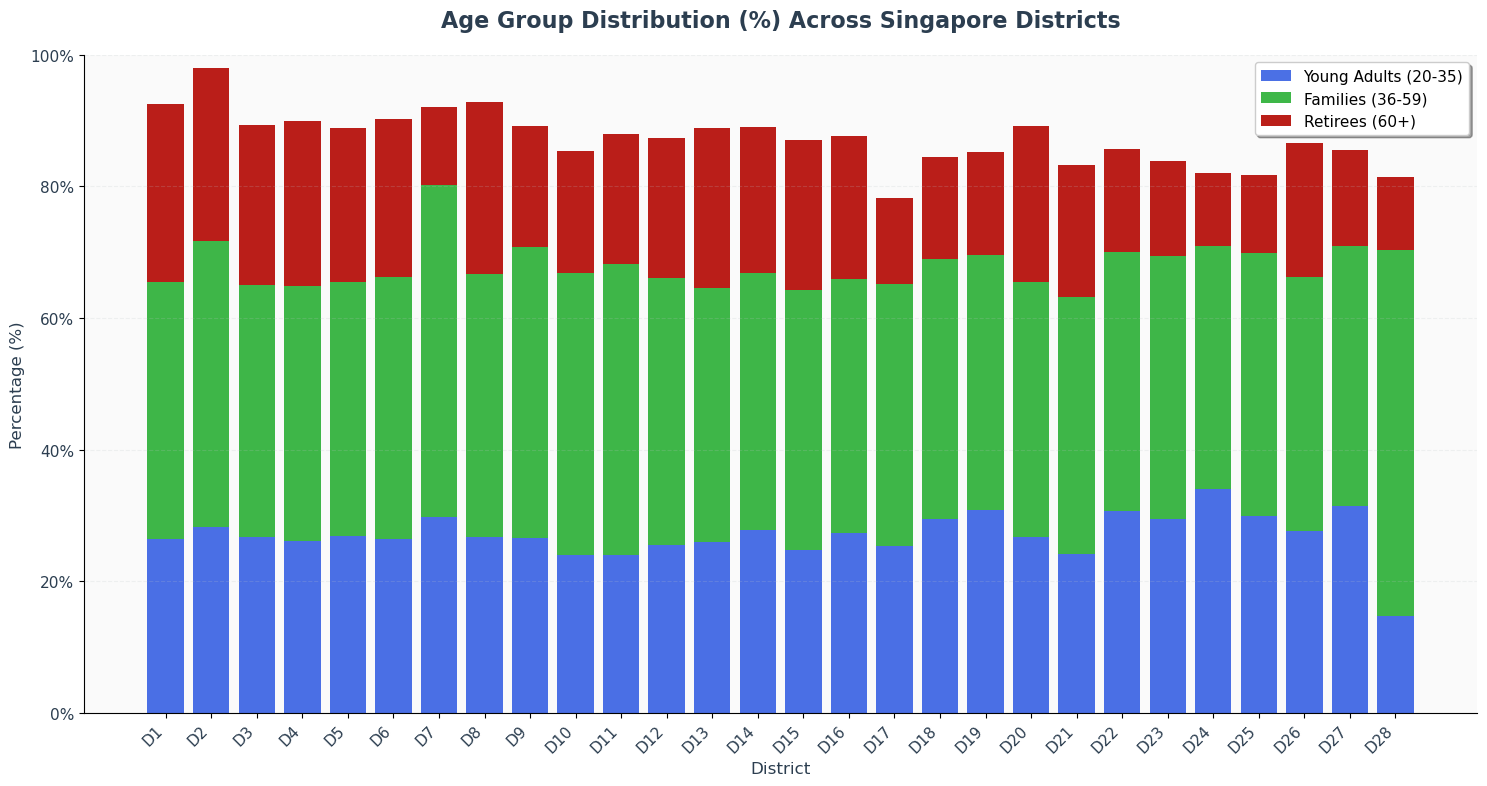

Districts with highest concentration of Young Adults:
D24.0: 34.0%
D27.0: 31.4%
D19.0: 30.9%
D22.0: 30.7%
D25.0: 30.0%

Districts with highest concentration of Families:
D28.0: 55.6%
D7.0: 50.4%
D9.0: 44.2%
D11.0: 44.2%
D2.0: 43.5%

Districts with highest concentration of Retirees:
D1.0: 27.0%
D2.0: 26.3%
D8.0: 26.2%
D4.0: 25.2%
D3.0: 24.4%


In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 8))

districts = [f'D{d}' for d in district_standardized['District']]
young_adults_pct = district_standardized['Young_Adults_Pct']
families_pct = district_standardized['Families_Pct']
retirees_pct = district_standardized['Retirees_Pct']

bars1 = plt.bar(districts, young_adults_pct, label='Young Adults (20-35)', color='#3760e3', alpha=0.9)
bars2 = plt.bar(districts, families_pct, bottom=young_adults_pct, label='Families (36-59)', color='#29af34', alpha=0.9)
bars3 = plt.bar(districts, retirees_pct, bottom=young_adults_pct + families_pct, label='Retirees (60+)', color='#b30600', alpha=0.9)

plt.title('Age Group Distribution (%) Across Singapore Districts', fontsize=16, fontweight='bold', pad=20, color='#2C3E50')
plt.xlabel('District', fontsize=12, color='#2C3E50')
plt.ylabel('Percentage (%)', fontsize=12, color='#2C3E50')
plt.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
plt.grid(axis='y', alpha=0.2, linestyle='--', color='#BDC3C7')

plt.xticks(rotation=45, ha='right', color='#2C3E50')
plt.yticks(color='#2C3E50')

plt.ylim(0, 100)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}%'))

# Set background color
plt.gca().set_facecolor('#FAFAFA')
plt.gcf().patch.set_facecolor('white')

plt.tight_layout()
plt.show()

print("Districts with highest concentration of Young Adults:")
top_young = district_standardized.nlargest(5, 'Young_Adults_Pct')[['District', 'Young_Adults_Pct']]
for _, row in top_young.iterrows():
    print(f"D{row['District']}: {row['Young_Adults_Pct']}%")

print("\nDistricts with highest concentration of Families:")
top_families = district_standardized.nlargest(5, 'Families_Pct')[['District', 'Families_Pct']]
for _, row in top_families.iterrows():
    print(f"D{row['District']}: {row['Families_Pct']}%")

print("\nDistricts with highest concentration of Retirees:")
top_retirees = district_standardized.nlargest(5, 'Retirees_Pct')[['District', 'Retirees_Pct']]
for _, row in top_retirees.iterrows():
    print(f"D{row['District']}: {row['Retirees_Pct']}%")